In [14]:
from mnist import load_mnist
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import time
import matplotlib.pyplot as plt

In [6]:
train, validation, test = load_mnist()

Successfully downloaded train-images-idx3-ubyte.gz 9912422 bytes.
Extracting MNIST-data\train-images-idx3-ubyte.gz
Successfully downloaded train-labels-idx1-ubyte.gz 28881 bytes.
Extracting MNIST-data\train-labels-idx1-ubyte.gz
Successfully downloaded t10k-images-idx3-ubyte.gz 1648877 bytes.
Extracting MNIST-data\t10k-images-idx3-ubyte.gz
Successfully downloaded t10k-labels-idx1-ubyte.gz 4542 bytes.
Extracting MNIST-data\t10k-labels-idx1-ubyte.gz


Размер массива картинок X: (55000, 28, 28, 1)
Размер массива меток labels: (55000,)
 Визуализация примеров (Пункт 2) ---


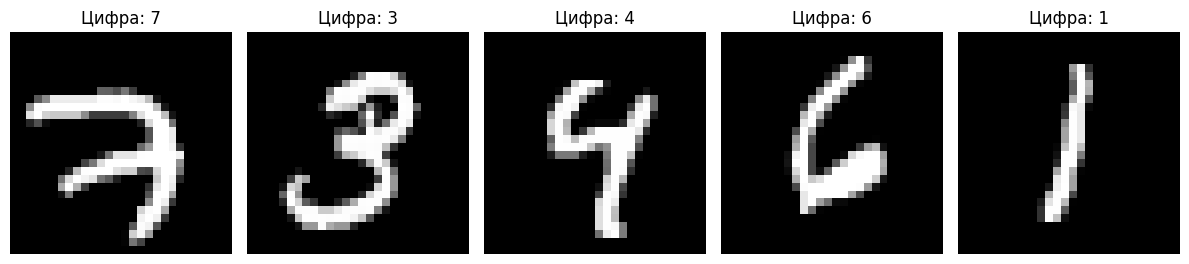

In [10]:
X = train[0]
labels = train[1]

print(f"Размер массива картинок X: {X.shape}")
print(f"Размер массива меток labels: {labels.shape}")

print(" Визуализация примеров (Пункт 2) ---")
    
    
num_examples = 5
    
fig, axes = plt.subplots(1, num_examples, figsize=(12, 4))
    
for i in range(num_examples):
        
    image = X[i]
    label = labels[i]
        
   
    image_reshaped = image.reshape(28, 28)
        
    axes[i].imshow(image_reshaped, cmap='gray')
    axes[i].set_title(f"Цифра: {label}")
        
        
    axes[i].axis('off')

    # Отображаем график
plt.tight_layout()
plt.show()


In [26]:
class my_PCA(): 
    def __init__(self, n_components=None): 
        self.n_components = n_components
        self.mean = None
        self.components = None
        self.eigenvalues = None
        
    def fit(self, X):
        # 1
        self.mean = np.mean(X, axis=0)
        X_c = X - self.mean
        # 2
        cov_matrix = np.dot(X_c.T, X_c)
        #3
        eig_vals, eig_vecs = np.linalg.eigh(cov_matrix)

        
        # Сортируем индексы 
        sorted_indices = np.argsort(eig_vals)[::-1]
        
        # Переупорядочиваем значения и векторы
        self.eigenvalues = eig_vals[sorted_indices]
        sorted_components = eig_vecs[:, sorted_indices]

       
        if self.n_components is not None:
            self.components = sorted_components[:, :self.n_components]
        else:
            self.components = sorted_components
        
    def transform(self, X): 
        X_c = X - self.mean
        return np.dot(X_c, self.components)
        
    def fit_transform(self, X): 
        self.fit(X)
        return self.transform(X)


    

In [12]:
class my_kNN(): 
    def __init__(self, n_neighbors=5): 
        self.n_neighbors  = n_neighbors 
        self.X_train = None
        self.y_train = None
        
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        
    def predict(self, X): 
        y_pred = []

        for i, x in enumerate(X):
            # Евклидово расстояние от точки x до всех точек X_train
            # axis=1 суммирует по признакам
            distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
            
            # Находим индексы k ближайших соседей (сортировка)
            k_indices = np.argsort(distances)[:self.n_neighbors]
            
            # Получаем метки этих соседей
            k_nearest_labels = self.y_train[k_indices]
            
            # Голосование: находим самый частый класс
            # bincount работает только с неотрицательными интами, что подходит для меток классов MNIST
            most_common = np.bincount(k_nearest_labels).argmax()
            y_pred.append(most_common)
            
            if i % 100 == 0 and i > 0:
                print(f"kNN предсказано: {i}/{len(X)}")
                
        return np.array(y_pred)

In [18]:
# Преобразуем картинки из (N, 28, 28, 1) в (N, 784)
    # load_mnist возвращает кортежи (images, labels)
train_set, validation_set, test_set = load_mnist()
    
    # Объединим train и validation для полного контроля над разбиением
X = np.concatenate((train_set[0], validation_set[0]), axis=0)
y = np.concatenate((train_set[1], validation_set[1]), axis=0)
    

X = X.reshape(X.shape[0], -1).astype(np.float32)
    
 # Для ускорения работы (так как kNN очень медленный на 60000 примерах)
    # возьмем подвыборку. Для финальной сдачи можно увеличить эти значения.
SAMPLE_SIZE = 5000 
X = X[:SAMPLE_SIZE]
y = y[:SAMPLE_SIZE]
    
# Разбиение на train/test (используем sklearn как в задании)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Extracting MNIST-data\train-images-idx3-ubyte.gz
Extracting MNIST-data\train-labels-idx1-ubyte.gz
Extracting MNIST-data\t10k-images-idx3-ubyte.gz
Extracting MNIST-data\t10k-labels-idx1-ubyte.gz
Размер обучающей выборки: (4000, 784)
Размер тестовой выборки: (1000, 784)



--- 3. Анализ PCA ---


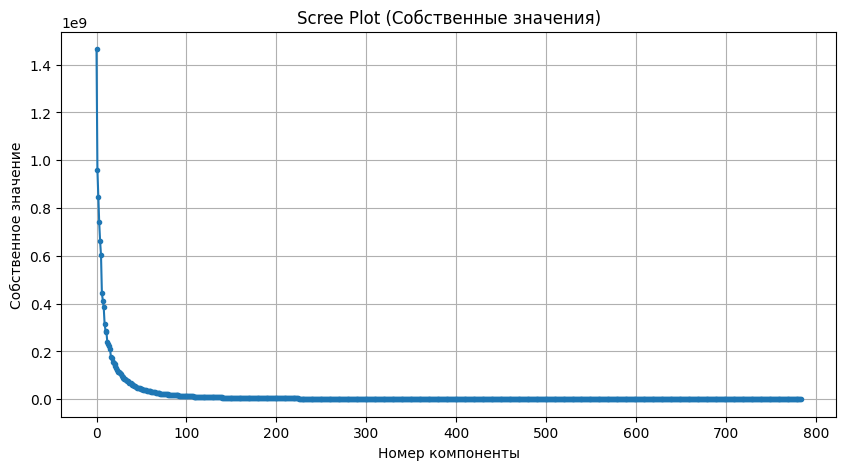

In [21]:

print("\n--- 3. Анализ PCA ---")
pca = my_PCA(n_components=None) # Вычисляем все компоненты
pca.fit(X_train)
    
    # График собственных значений (Scree plot)
plt.figure(figsize=(10, 5))
plt.plot(pca.eigenvalues, marker='.')
plt.title("Scree Plot (Собственные значения)")
plt.xlabel("Номер компоненты")
plt.ylabel("Собственное значение")
plt.grid()
plt.show()

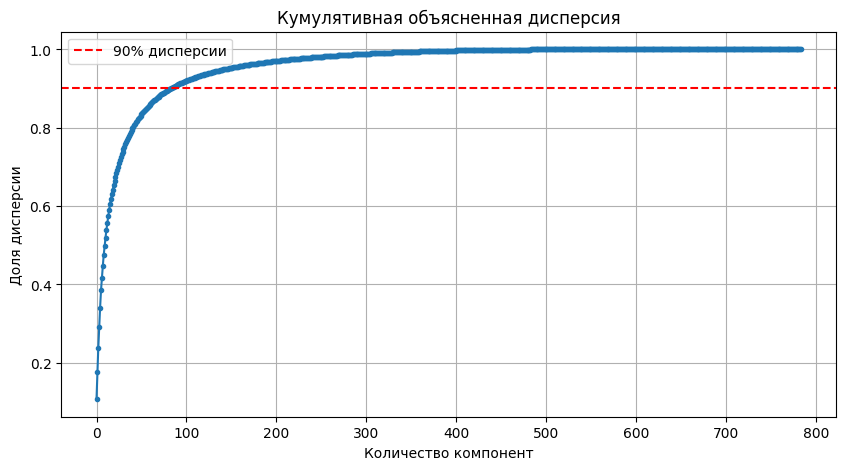

In [36]:
# График кумулятивной дисперсии
total_variance = np.sum(pca.eigenvalues)
explained_variance_ratio = pca.eigenvalues / total_variance
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(10, 5))
plt.plot(cumulative_variance, marker='.')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% дисперсии')
plt.title("Кумулятивная объясненная дисперсия")
plt.xlabel("Количество компонент")
plt.ylabel("Доля дисперсии")
plt.legend()
plt.grid()
plt.show()

Доля дисперсии первых 15 компонент: 0.5894


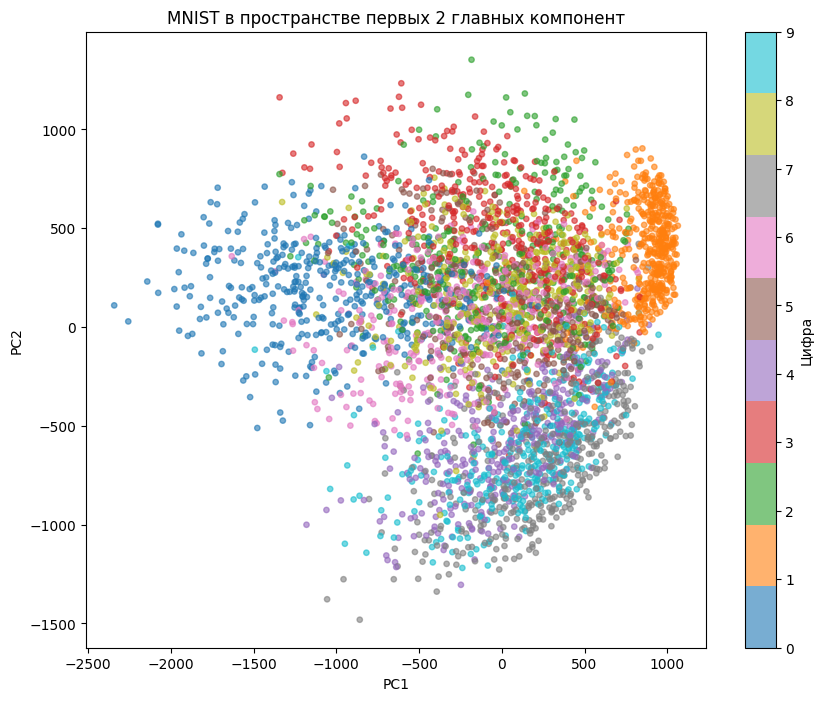

In [40]:
# Сколько компонент нужно для 15? (по заданию посмотреть долю)
print(f"Доля дисперсии первых 15 компонент: {cumulative_variance[14]:.4f}")

# Визуализация в 2D (первые 2 компоненты)
pca_2d = my_PCA(n_components=2)
X_train_2d = pca_2d.fit_transform(X_train)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap='tab10', alpha=0.6, s=15)
plt.colorbar(scatter, label='Цифра')
plt.title("MNIST в пространстве первых 2 главных компонент")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [30]:
print("\n--- 4. Тестирование kNN на исходных данных ---")
# Создаем классификатор my_kNN (k=5)
knn = my_kNN(n_neighbors=5)
knn.fit(X_train, y_train)

print("Предсказание на исходных данных (может занять время)...")
start_time = time.time()
y_pred_raw = knn.predict(X_test)
end_time = time.time()

acc_raw = accuracy_score(y_test, y_pred_raw)
print(f"Точность kNN на сырых данных: {acc_raw:.4f}")
print(f"Время выполнения: {end_time - start_time:.2f} сек")

if acc_raw < 0.15:
    print("Точность слишком низкая, возможно ошибка в алгоритме!")

print("\n 5. Оптимизация kNN с PCA (Grid Search) ---")

best_acc = 0
best_params = {}

# Диапазоны для поиска ( 1-64 компоненты и 1-30 соседей)
# Можно расширить диапазоны, если компьютер мощный.
components_range = [1, 5, 10, 20, 40, 64]
neighbors_range = [1, 3, 5, 10, 15, 30] 

print(f"Перебор параметров: Компоненты={components_range}, Соседи={neighbors_range}")

# Предварительно обучим PCA на макс. количество из диапазона, чтобы не пересчитывать
max_comp = max(components_range)
pca_full = my_PCA(n_components=max_comp)
pca_full.fit(X_train)
X_train_transformed_full = pca_full.transform(X_train)
X_test_transformed_full = pca_full.transform(X_test)

for n_comp in components_range:
    # Берем срез уже посчитанных данных
    X_train_pca = X_train_transformed_full[:, :n_comp]
    X_test_pca = X_test_transformed_full[:, :n_comp]
    
    for k in neighbors_range:
        knn_search = my_kNN(n_neighbors=k)
        knn_search.fit(X_train_pca, y_train)
        
        y_pred_pca = knn_search.predict(X_test_pca)
        acc = accuracy_score(y_test, y_pred_pca)
        
        print(f"PCA Comp: {n_comp}, k: {k} , точность: {acc:.4f}")
        
        if acc > best_acc:
            best_acc = acc
            best_params = {'n_components': n_comp, 'n_neighbors': k}

print("\n================ ИТОГИ ================")
print(f"Лучшая точность: {best_acc:.4f}")
print(f"Лучшие параметры: {best_params}")
print("=======================================")



--- 4. Тестирование kNN на исходных данных ---
Предсказание на исходных данных (может занять время)...
kNN предсказано: 100/1000
kNN предсказано: 200/1000
kNN предсказано: 300/1000
kNN предсказано: 400/1000
kNN предсказано: 500/1000
kNN предсказано: 600/1000
kNN предсказано: 700/1000
kNN предсказано: 800/1000
kNN предсказано: 900/1000
Точность kNN на сырых данных: 0.9260
Время выполнения: 16.62 сек

 5. Оптимизация kNN с PCA (Grid Search) ---
Перебор параметров: Компоненты=[1, 5, 10, 20, 40, 64], Соседи=[1, 3, 5, 10, 15, 30]
kNN предсказано: 100/1000
kNN предсказано: 200/1000
kNN предсказано: 300/1000
kNN предсказано: 400/1000
kNN предсказано: 500/1000
kNN предсказано: 600/1000
kNN предсказано: 700/1000
kNN предсказано: 800/1000
kNN предсказано: 900/1000
PCA Comp: 1, k: 1 -> Accuracy: 0.2620
kNN предсказано: 100/1000
kNN предсказано: 200/1000
kNN предсказано: 300/1000
kNN предсказано: 400/1000
kNN предсказано: 500/1000
kNN предсказано: 600/1000
kNN предсказано: 700/1000
kNN предсказан